## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


**Team 30**

A01796272 - Luis Antonio Ramirez Martinez

A01796323 - Benjamin Cisneros Barraza

A01796363 - Arthur Jafed Zizumbo Velasco

A01796937 - Sandra Luz Cervantes Espinoza

Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


## Import libraries

We import the following libraries:

- **torch**: the main deep learning framework used to build and train the Recurrent Neural Network (RNN) model.

- **torch.nn**: provides neural network layers such as `Embedding`, `LSTM`, and `Linear`, which are used to construct the text classification model.

- **torch.optim**: used to define optimization algorithms such as **Adam**, which updates the model parameters during training.

- **sklearn.metrics**: used to evaluate the performance of the model. In this project it is used to compute the **confusion matrix** for analyzing classification results.

- **matplotlib**: used to visualize the confusion matrix and other potential plots related to model performance.

- **numpy**: used for numerical operations and array manipulations when processing predictions and labels.

These libraries allow us to build, train, evaluate, and visualize the performance of the RNN-based text classification model using the **AG_NEWS dataset**.

In [1]:
# The following libraries are required for running the given code
import numpy as np
import scipy
# Patch removed scipy.interp for compatibility with scikitplot
scipy.interp = np.interp

# PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# Neural layers
from torch import nn

# Libraries to plot the confusion matrix
import matplotlib.pyplot as plt
import scikitplot as skplt
from sklearn.metrics import classification_report
import torch


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/envs/amlm-env-A3b/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/amlm-env-A3b/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/envs/amlm-env-A3b/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_lo

### Device Configuration

PyTorch supports multiple hardware backends. This cell detects and selects the best available device:

- **CUDA**: NVIDIA GPU — highest performance for deep learning.
- **MPS**: Apple Metal Performance Shaders — available on M1/M2/M3 Macs.
- **CPU**: Fallback when no GPU is available.

Moving the model and tensors to the same device is required for correct and efficient training.

In [2]:
# -----------------------------------------------------------------------------
# Device Selection: CUDA (NVIDIA GPU), MPS (Apple Silicon), or CPU
# -----------------------------------------------------------------------------
# This block determines the best available hardware accelerator for PyTorch.
# Priority:
#   1) CUDA  - If an NVIDIA GPU is available.
#   2) MPS   - If running on macOS with Apple Silicon (M1/M2/M3) and Metal backend.
#   3) CPU   - Fallback option when no GPU acceleration is available.
# -----------------------------------------------------------------------------

# Check if CUDA is available (NVIDIA GPUs)
if torch.cuda.is_available():
    device = torch.device('cuda')

# If not, check for Apple's Metal Performance Shaders (MPS) backend
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')

# If neither CUDA nor MPS is available, default to CPU
else:
    device = torch.device('cpu')

# Print the selected device for confirmation
print(f"[INFO] Device: {device}")

[INFO] Device: mps


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

### Dataset Preparation

The **AG_NEWS** dataset contains news articles labeled into 4 categories: World, Sports, Business, and Sci/Tech. It provides 120,000 training samples and 7,600 test samples.

- `AG_NEWS()`: downloads and loads the dataset as an iterable of `(label, text)` pairs.
- `to_map_style_dataset()`: converts the iterable into a map-style dataset that supports indexing, required by PyTorch's `DataLoader` and `random_split`.

In [3]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

#### Tokenizer

A tokenizer splits raw text into individual tokens (words, punctuation). We use PyTorch's `basic_english` tokenizer, which lowercases text and separates punctuation from words.

`yield_tokens` is a generator that iterates over the dataset and yields token lists. It is used by `build_vocab_from_iterator` to construct the vocabulary from the training data.

In [4]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

#### Vocabulary

The vocabulary maps each unique token to an integer index. We build it from the training data only (never from the test set) to avoid data leakage.

- `specials=["<unk>"]`: reserves index 0 for unknown tokens — words not seen during training.
- `set_default_index`: ensures any out-of-vocabulary token maps to `<unk>` instead of raising an error at inference time.

In [5]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [6]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


#### Train / Validation Split

We split the original 120,000 training samples into:

- **Training set (90% — 108,000 samples)**: used to update model weights during backpropagation.
- **Validation set (10% — 12,000 samples)**: used to monitor generalization after each epoch, without touching the test set.

The **test set (7,600 samples)** remains held out and is only used for final evaluation.

In [7]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [8]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [9]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


#### Batch Configuration

- `labels`: human-readable category names for the 4 AG_NEWS classes (used for display and the confusion matrix).
- `max_tokens`: maximum sequence length per sample. Texts longer than 50 tokens are truncated; shorter ones are zero-padded. This ensures all sequences in a batch have the same length.
- `BATCH_SIZE`: number of samples processed per training step. Larger batches are faster but require more memory.

In [10]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

#### Collate Function

`collate_batch` is passed to the `DataLoader` to process each raw batch into tensors:

1. Separates labels and raw text strings from each sample.
2. Tokenizes each text and converts tokens to integer IDs via the vocabulary.
3. Pads short sequences with zeros and truncates long ones to `max_tokens` — ensuring uniform shape within the batch.
4. Returns tensors of type `long` (int64), which is required by the PyTorch `Embedding` layer.
5. Shifts labels from range 1–4 to 0–3 for compatibility with `CrossEntropyLoss`.

In [11]:
def collate_batch(batch):
    # Separate labels (y) and texts (x) from the batch
    y, x = list(zip(*batch))

    # Convert each text into a sequence of token IDs using the tokenizer and vocabulary
    token_ids = [vocab(tokeniser(text)) for text in x]

    # Apply padding or truncation so every sequence has the same length
    padded_tokens = [
        tokens + [0] * (max_tokens - len(tokens)) if len(tokens) < max_tokens
        else tokens[:max_tokens]
        for tokens in token_ids
    ]

    # Convert sequences to PyTorch tensors (int64 required for embeddings)
    x_tensor = torch.tensor(padded_tokens, dtype=torch.long)

    # Convert labels to tensor and shift from 1–4 to 0–3
    y_tensor = torch.tensor(y, dtype=torch.long) - 1

    # Return processed inputs and labels
    return x_tensor, y_tensor

#### DataLoaders

`DataLoader` wraps a dataset and handles batching, shuffling, and parallel data loading. We create three loaders:

- **`train_loader`**: shuffled each epoch so the model does not overfit to the sample order.
- **`val_loader`**: used after each epoch to evaluate generalization on unseen data.
- **`test_loader`**: used only after training is complete for the final performance report.

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### RNN Model

We implement an RNN-based text classifier using an **LSTM** (Long Short-Term Memory) network. LSTMs are well-suited for sequential data like text because they maintain a hidden state that can capture long-range dependencies between words, mitigating the vanishing gradient problem present in vanilla RNNs.

The model hyperparameters below control the capacity and complexity of the network.

In [13]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

#### Model Architecture

The `RNN_Model_1` class consists of three main components:

1. **Embedding layer** (`nn.Embedding`): maps each token ID to a dense vector of size `EMBEDDING_SIZE` (300). This allows the model to learn semantic representations of words during training.

2. **LSTM layer** (`nn.LSTM`): a 2-layer bidirectional-ready recurrent network that processes the sequence of embeddings step by step. The final hidden state `h_n[-1]` captures a compressed representation of the entire input sequence.

3. **Fully connected layer** (`nn.Linear`): a linear classifier that projects the LSTM hidden state (256 dimensions) onto the 4 output classes. Raw logits are returned — softmax is applied implicitly by `CrossEntropyLoss` during training.

In [14]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()

        # Embedding layer that converts word IDs into dense vector representations
        self.embedding_layer = nn.Embedding(
            num_embeddings=len(vocab),
            embedding_dim=embed_size
        )

        # Recurrent layer (LSTM), processes the sequence of word embeddings
        # and learns temporal dependencies in the text
        self.rnn = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True
        )

        # Fully connected layer, maps the hidden representation
        # to the final number of output classes
        self.fc = nn.Linear(
            in_features=hidden,
            out_features=num_classes
        )

    def forward(self, x):
        # x shape: [batch_size, sequence_length]

        # Convert token IDs into embeddings
        embedded = self.embedding_layer(x)  # shape: [batch, seq_len, embed_dim]

        # Pass embeddings through the LSTM
        # output: hidden states for all time steps
        # h_n: final hidden state for each layer
        output, (h_n, c_n) = self.rnn(embedded)

        # Take the last hidden state from the final LSTM layer
        # This represents the full sequence information
        last_hidden_state = h_n[-1]  # shape: [batch_size, hidden_size]

        # Pass the representation to the classifier
        logits = self.fc(last_hidden_state)

        return logits

### Accuracy Function

Computes the fraction of correctly classified samples over a full `DataLoader`. Key implementation details:

- `model.eval()`: disables dropout and batch normalization (if present) during inference.
- `torch.no_grad()`: disables gradient computation to reduce memory usage and speed up evaluation.
- Data is moved to the same device as the model before each forward pass.

In [15]:
def accuracy(model, loader):
    """Computes the accuracy of the model over the given DataLoader."""
    device = next(model.parameters()).device
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            # Move data to the same device as the model
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

### Training Function

Implements the standard supervised learning loop over multiple epochs:

1. Set the model to training mode (`model.train()`).
2. For each batch: move data to device → forward pass → compute loss → backpropagate → update weights.
3. `CrossEntropyLoss` combines a softmax activation with negative log-likelihood loss, suitable for multi-class classification.
4. `optimiser.zero_grad()` clears gradients from the previous step before computing new ones.

In [16]:
def train(model, optimiser, train_loader, epochs=10):
    """Trains the model for the given number of epochs."""
    device = next(model.parameters()).device

    # Loss function for multi-class classification
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            # Move data to the same device as the model
            x = x.long().to(device)
            y = y.long().to(device)

            # Zero gradients from the previous step
            optimiser.zero_grad()

            # Forward pass
            outputs = model(x)
            loss = criterion(outputs, y)

            # Backward pass and parameter update
            loss.backward()
            optimiser.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

In [17]:
epochs = 3
lr = 0.001

# Instantiate model and move it to the available device (MPS / CUDA / CPU)
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES).to(device)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

In [ ]:
train(rnn_model, optimiser=optimiser, train_loader=train_loader, epochs=epochs)

print("Train Accuracy:", accuracy(rnn_model, train_loader))
print("Val Accuracy:", accuracy(rnn_model, val_loader))
print("Test Accuracy:", accuracy(rnn_model, test_loader))

In [ ]:
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.9058


In [ ]:
def sample_text(model, text):
    """
    Classifies a raw input text string using the trained model.

    Args:
        model: trained RNN model
        text (str): input text to classify

    Returns:
        str: predicted category label
    """
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        # Tokenize and convert to token IDs using the vocabulary
        token_ids = vocab(tokeniser(text))

        # Pad or truncate to max_tokens
        if len(token_ids) < max_tokens:
            token_ids = token_ids + [0] * (max_tokens - len(token_ids))
        else:
            token_ids = token_ids[:max_tokens]

        # Add batch dimension and move to device
        x = torch.tensor([token_ids], dtype=torch.long).to(device)

        # Forward pass
        output = model(x)
        pred = output.argmax(dim=1).item()

    print(f"Text     : {text}")
    print(f"Predicted: {labels[pred]}")
    return labels[pred]

In [ ]:
# Test the sampling function with raw text examples
sample_text(rnn_model, "Apple releases a new MacBook with an M4 chip that doubles performance benchmarks.")
print()
sample_text(rnn_model, "The stock market experienced a sharp decline after the Fed raised interest rates.")
print()
sample_text(rnn_model, "Brazil wins the World Cup final against Argentina in a dramatic penalty shootout.")
print()
sample_text(rnn_model, "World leaders gather in Geneva to discuss a new climate change agreement.")

Text     : Apple releases a new MacBook with an M4 chip that doubles performance benchmarks.
Predicted: Sci/Tech

Text     : The stock market experienced a sharp decline after the Fed raised interest rates.
Predicted: Business

Text     : Brazil wins the World Cup final against Argentina in a dramatic penalty shootout.
Predicted: Sports

Text     : World leaders gather in Geneva to discuss a new climate change agreement.
Predicted: World


'World'

In [ ]:
def plot_confusion_matrix(model, loader, labels):
    """Plots the normalized confusion matrix for the model on the given DataLoader."""

    # Move model to the available device
    model = model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    # Disable gradients for evaluation
    with torch.no_grad():

        for x, y in loader:

            # Move batch to the same device as the model
            x = x.to(device)
            y = y.to(device)

            # Forward pass
            outputs = model(x)

            # Get predicted class index
            preds = outputs.argmax(dim=1)

            # Collect results on CPU for plotting
            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    # Plot normalized confusion matrix
    skplt.metrics.plot_confusion_matrix(
        y_true,
        y_pred,
        figsize=(8, 8),
        normalize=True
    )

    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.title("Confusion Matrix - AG_NEWS")
    plt.show()

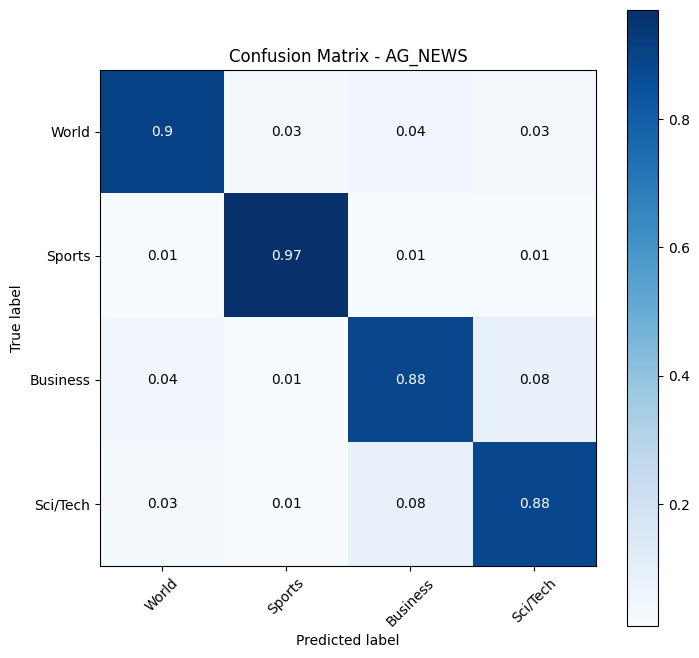

In [ ]:
plot_confusion_matrix(rnn_model, test_loader, labels)

Model metrics

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, loader):
    """Prints a full classification report (precision, recall, F1) per class."""
    device = next(model.parameters()).device
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for texts, lbls in loader:

            texts = texts.to(device)
            lbls = lbls.to(device)

            outputs = model(texts)
            predicted = outputs.argmax(dim=1)

            y_true.extend(lbls.cpu().tolist())
            y_pred.extend(predicted.cpu().tolist())

    print(classification_report(
        y_true,
        y_pred,
        target_names=["World", "Sports", "Business", "Sci/Tech"]
    ))


evaluate_model(rnn_model, test_loader)

Model predictions

In [ ]:
def show_predictions(model, loader, num_examples=5):

    device = next(model.parameters()).device
    model.eval()

    labels_map = ["World","Sports","Business","Sci/Tech"]

    with torch.no_grad():
        for texts, labels in loader:

            texts = texts.to(device)
            outputs = model(texts)
            preds = outputs.argmax(dim=1)

            for i in range(num_examples):

                print("Prediction:", labels_map[preds[i]])
                print("Real:", labels_map[labels[i]])
                print("-"*50)

            break


show_predictions(rnn_model, test_loader)

Prediction: Sports
Real: Sports
--------------------------------------------------
Prediction: Sports
Real: Sports
--------------------------------------------------
Prediction: Business
Real: Business
--------------------------------------------------
Prediction: Sci/Tech
Real: Sci/Tech
--------------------------------------------------
Prediction: World
Real: World
--------------------------------------------------
